In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [110]:
len_fit = 500
fitness = np.zeros(len_fit) #initiating array with lots of extra entries
k_star = 50 #threshold
for i in range(len_fit):
    if i < k_star:
        fitness[i] = 1 + i*0.05
    else:
        fitness[i] = 1 + k_star*0.05

In [112]:
rng = np.random.default_rng()

In [117]:
#fitness = np.ones(len_fit)*3
#fitness[0] = 1
cells = np.zeros(len_fit)
k0 = 100
cells[k0] = 1
total_pop = 1

while total_pop < 100_000:
    rates = cells*fitness
    k_ind = rng.choice(len_fit, p = rates/np.sum(rates))
    k1 = rng.binomial(2*k_ind, 0.5)
    k2 = 2*k_ind - k1
    #print(k_ind, k1, k2)
    cells[k_ind] -= 1
    cells[k1] += 1
    cells[k2] += 1
    total_pop += 1

Text(0, 0.5, 'cell count')

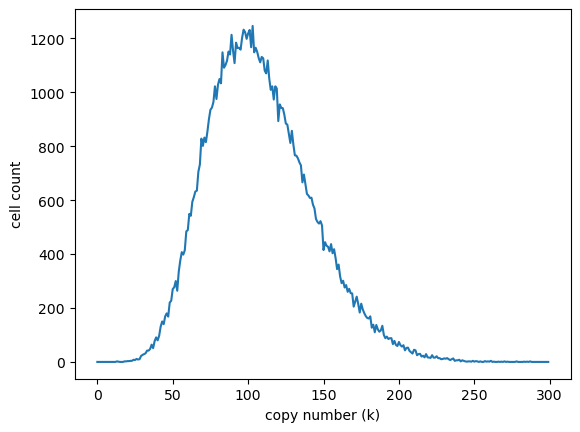

In [118]:
plt.plot(np.arange(300), cells[0:300])
plt.xlabel('copy number (k)')
plt.ylabel('cell count')

In [145]:
def fitness(k_star, alpha, array_len=500): 
    fitness = np.zeros(array_len)
    for i in range(len(fitness)):
        if i < k_star:
            fitness[i] = 1 + i*alpha
        else:
            fitness[i] = 1 + k_star*alpha
    return fitness
    
def run_simulation(num_runs, fitness, array_len = 500, k0 = 100, max_cells = 100_000):
    cell_pops = np.zeros((num_runs, array_len))
    for run in range(num_runs): 
        cells = np.zeros(array_len)
        cells[k0] = 1
        total_pop = 1

        while total_pop < max_cells:
            rates = cells*fitness
            k_ind = rng.choice(len_fit, p = rates/np.sum(rates))
            k1 = rng.binomial(2*k_ind, 0.5)
            k2 = 2*k_ind - k1

            cells[k_ind] -= 1
            cells[k1] += 1
            cells[k2] += 1
            total_pop += 1

        cell_pops[run] = cells
        
    return cell_pops

In [147]:
fit = fitness(100, 0.1)
test = run_simulation(100, fit)

In [149]:
test_mean = np.mean(test, axis = 0)
test_std = np.std(test, axis = 0)

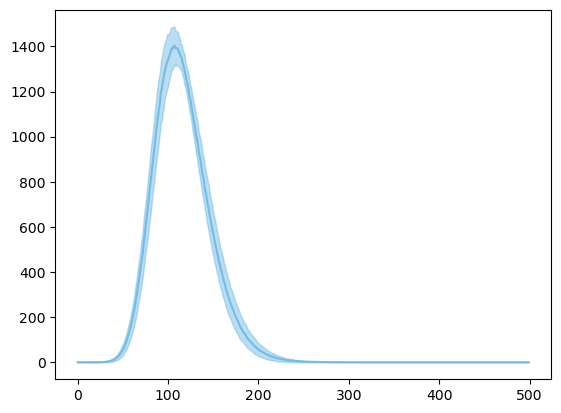

In [150]:
plt.fill_between(np.arange(500), test_mean - test_std, test_mean + test_std, color = '#75BCE5', alpha = 0.5)
plt.plot(np.arange(500), test_mean, color = '#75BCE5')

In [177]:
#comparing results from my simulation to the author's simulation
data = np.loadtxt('ecDNA_Simulations/NonNeutralSummaryPC3.txt')

In [154]:
fit = np.ones(len_fit)*3
fit[0] = 1
cells = np.zeros(len(fit))
k0 = 100
cells[k0] = 1
total_pop = 1

while total_pop < 100_000:
    rates = cells*fit
    k_ind = rng.choice(len_fit, p = rates/np.sum(rates))
    k1 = rng.binomial(2*k_ind, 0.5)
    k2 = 2*k_ind - k1
    #print(k_ind, k1, k2)
    cells[k_ind] -= 1
    cells[k1] += 1
    cells[k2] += 1
    total_pop += 1

In [174]:
fit = np.ones(len_fit)*3
fit[0] = 1
comparison_test = run_simulation(10, fit)

In [165]:
data_plot = np.zeros((10, 309))
for i in range(10):
    row = np.histogram(data[i,:], bins = np.arange(0, 310))[0]
    data_plot[i] = row

Text(0, 0.5, 'cell count')

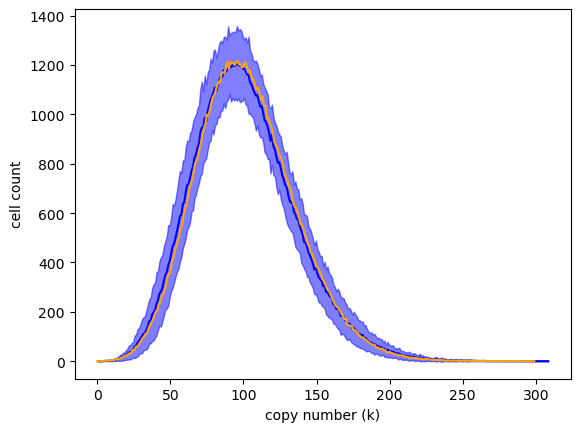

In [176]:
#plt.hist(data[0, :], bins = 300, histtype = 'step');
plt.plot(np.arange(0.5, 309.5, 1), np.mean(data_plot, axis = 0), color = 'blue')
plt.fill_between(np.arange(0.5, 309.5, 1), np.mean(data_plot, axis = 0) - np.std(data_plot, axis = 0)
                 , np.mean(data_plot, axis = 0) + np.std(data_plot, axis = 0), color = 'blue', alpha = 0.5)
plt.plot(np.arange(300), np.mean(comparison_test, axis = 0)[0:300], color = 'orange')
plt.xlabel('copy number (k)')
plt.ylabel('cell count')